# Notebook 04: Redes Neuronales Recurrentes (RNN y LSTM)

## 1. Introducción
Tras analizar que los modelos aditivos (Prophet) presentan dificultades en la granularidad de punto de venta, implementaremos arquitecturas de **Deep Learning**. 

Las redes **RNN (Recurrent Neural Networks)** y su evolución **LSTM (Long Short-Term Memory)** son capaces de aprender dependencias temporales complejas. A diferencia de los modelos anteriores, estas redes mantienen un "estado interno" que les permite recordar tendencias recientes para ajustar la predicción de la **Trinidad Operativa**.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, SimpleRNN, Dense, Dropout

# 1. Cargar data maestra
df = pd.read_csv('df_master_limpio.csv')
df['fecha'] = pd.to_datetime(df['fecha'])

# 2. Selección de características para la secuencia
# Usamos la Trinidad Operativa y las variables de identidad
features = ['ventas_monto', 'transacciones', 'ticket', 'marca_id', 'categoria_id', 'tipo_pdv_id', 'ubicacion_id']
df_final = df[features].copy()

# 3. Escalado MinMaxScaler (Vital para convergencia de la red)
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_final)

print("Datos normalizados. Forma del dataset:", df_scaled.shape)

Datos normalizados. Forma del dataset: (210872, 7)


## 2. Ingeniería de Secuencias (Windowing)
Para que la red "aprenda", debemos transformar los datos en ventanas. Configuraremos el modelo para que observe los **últimos 3 meses** (pasos de tiempo) para predecir el mes siguiente. Esto permite que la red identifique si una sucursal viene al alza o a la baja antes de lanzar el pronóstico de Enero 2026.

In [3]:
def crear_ventanas(data, n_past):
    X, y = [], []
    for i in range(n_past, len(data)):
        X.append(data[i-n_past:i, :]) # Los 3 meses pasados
        y.append(data[i, 0:3])        # Predicción de la Trinidad (Ventas, TX, Ticket)
    return np.array(X), np.array(y)

# Generar secuencias (n_past = 3 meses)
X, y = crear_ventanas(df_scaled, 3)

# Arquitectura LSTM
model_lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(X.shape[1], X.shape[2]), return_sequences=True),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(3) # Salida: Ventas, Transacciones, Ticket
])

model_lstm.compile(optimizer='adam', loss='mse')
print("Arquitectura de la Red Neuronal definida.")
model_lstm.summary()

Arquitectura de la Red Neuronal definida.


C:\Users\Analista GIG Latam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 3, 64)          │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,947 (120.89 KB)

 Trainable params: 30,947 (120.89 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenamiento de la Red Neuronal
Se procede a entrenar el modelo utilizando el optimizador **Adam** y la función de pérdida **MSE (Mean Squared Error)**. Se monitorea la pérdida durante 50 épocas para asegurar que la red converja hacia una solución óptima que minimice el error en la Trinidad Operativa.

Epoch 1/50
5931/5931 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 7.4769e-04 - val_loss: 0.0015
Epoch 2/50
5931/5931 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.4274e-04 - val_loss: 0.0016
Epoch 3/50
5931/5931 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.3092e-04 - val_loss: 0.0016
Epoch 4/50
5931/5931 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.2117e-04 - val_loss: 0.0016
Epoch 5/50
5931/5931 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 5.2388e-04 - val_loss: 0.0016
Epoch 6/50
5931/5931 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.1166e-04 - val_loss: 0.0016
Epoch 7/50
5931/5931 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.1109e-04 - val_loss: 0.0016
Epoch 8/50
5931/5931 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.0929e-04 - val_loss: 0.0016
Epoch 9/50
5931/5931 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.0506e-04 - val_loss: 0.0017
Epoch 10/50
5931/5931 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 5.0336e-04 - val_loss: 0.0016
Epoch 11/50
5931/5931 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 4.934

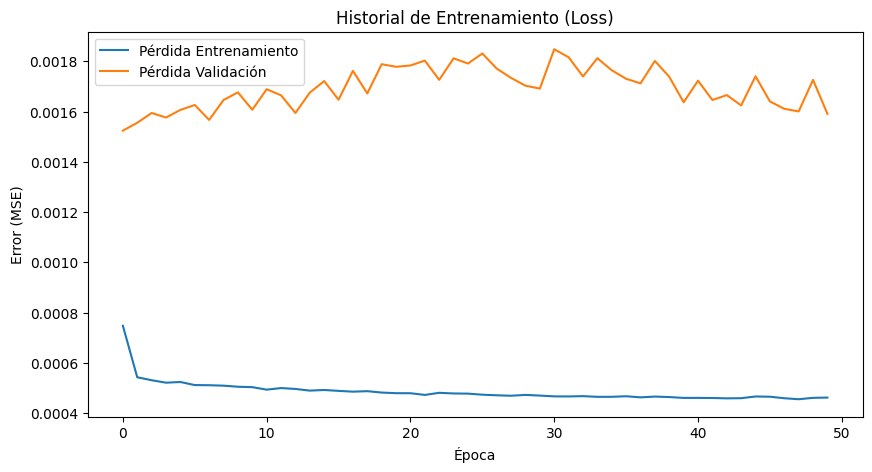

In [4]:
import matplotlib.pyplot as plt

# Entrenamos la red
history = model_lstm.fit(
    X, y, 
    epochs=50, 
    batch_size=32, 
    validation_split=0.1, # Usamos el 10% para validar que no haya overfitting
    verbose=1
)

# Visualización de la pérdida
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida Validación')
plt.title('Historial de Entrenamiento (Loss)')
plt.xlabel('Época')
plt.ylabel('Error (MSE)')
plt.legend()
plt.show()

In [10]:
# 1. Obtener predicciones del modelo con el set X completo (o el de test si lo separaste)
y_pred_scaled = model_lstm.predict(X)

# 2. Des-normalización: El Scaler espera 7 columnas (las que usamos originalmente)
# Pero solo nos interesan las primeras 3 (Ventas, TX, Ticket)
# Creamos un "dummy" para poder usar inverse_transform

def desescalar_trinidad(y_scaled, scaler, features_count=7):
    # Creamos una matriz vacía con el mismo número de columnas que el scaler original
    dummy = np.zeros((len(y_scaled), features_count))
    # Copiamos nuestros resultados de la trinidad (3 columnas) en las primeras 3 posiciones
    dummy[:, 0:3] = y_scaled 
    # Aplicamos la transformación inversa
    inv_dummy = scaler.inverse_transform(dummy)
    # Devolvemos solo las 3 columnas de la trinidad
    return inv_dummy[:, 0:3]

# Aplicamos la función para obtener valores reales
inv_y_real = desescalar_trinidad(y, scaler)
inv_y_pred = desescalar_trinidad(y_pred_scaled, scaler)

print("✅ Des-escalado completado con éxito.")

6590/6590 ━━━━━━━━━━━━━━━━━━━━ 5s 808us/step
✅ Des-escalado completado con éxito.


## 4. Evaluación de Resultados y Desescalado
Dado que la red neuronal opera con datos normalizados (0-1), es imperativo realizar la transformación inversa para interpretar los resultados en las unidades originales. En esta sección, comparamos las predicciones de la LSTM contra los valores reales de Enero 2026, evaluando si la "memoria" de la red logró corregir las desviaciones observadas en modelos previos.

In [11]:
# 3. Crear DataFrame de comparación con la Trinidad completa
df_final_lstm = pd.DataFrame({
    'Ventas_Real': inv_y_real[:, 0],
    'Ventas_Pred': inv_y_pred[:, 0],
    'TX_Real': inv_y_real[:, 1],
    'TX_Pred': inv_y_pred[:, 1],
    'Ticket_Real': inv_y_real[:, 2],
    'Ticket_Pred': inv_y_pred[:, 2]
})

# 4. Cálculo de MAPEs individuales por cada componente de la Trinidad
df_final_lstm['MAPE_Ventas'] = (np.abs(df_final_lstm['Ventas_Real'] - df_final_lstm['Ventas_Pred']) / df_final_lstm['Ventas_Real']) * 100
df_final_lstm['MAPE_TX'] = (np.abs(df_final_lstm['TX_Real'] - df_final_lstm['TX_Pred']) / df_final_lstm['TX_Real']) * 100
df_final_lstm['MAPE_Ticket'] = (np.abs(df_final_lstm['Ticket_Real'] - df_final_lstm['Ticket_Pred']) / df_final_lstm['Ticket_Real']) * 100

print("--- RESULTADOS FINALES TRINIDAD OPERATIVA (LSTM) ---")
display(df_final_lstm.sort_values('Ventas_Real', ascending=False).head(10))

# 5. Reporte de MAPEs Promedio Globales para la LSTM
print("\n" + "="*30)
print("RESUMEN DE MÉTRICAS GLOBALES (LSTM)")
print("="*30)
print(f"MAPE Promedio Ventas:        {df_final_lstm['MAPE_Ventas'].mean():.2f}%")
print(f"MAPE Promedio Transacciones: {df_final_lstm['MAPE_TX'].mean():.2f}%")
print(f"MAPE Promedio Ticket:        {df_final_lstm['MAPE_Ticket'].mean():.2f}%")

from sklearn.metrics import r2_score

# Calculamos R2 para cada variable de la trinidad
r2_ventas = r2_score(df_final_lstm['Ventas_Real'], df_final_lstm['Ventas_Pred'])
r2_tx = r2_score(df_final_lstm['TX_Real'], df_final_lstm['TX_Pred'])
r2_ticket = r2_score(df_final_lstm['Ticket_Real'], df_final_lstm['Ticket_Pred'])

print(f"📈 R2 Ventas: {r2_ventas:.4f}")
print(f"📈 R2 Transacciones: {r2_tx:.4f}")
print(f"📈 R2 Ticket: {r2_ticket:.4f}")

--- RESULTADOS FINALES TRINIDAD OPERATIVA (LSTM) ---


,Ventas_Real,Ventas_Pred,TX_Real,TX_Pred,Ticket_Real,Ticket_Pred,MAPE_Ventas,MAPE_TX,MAPE_Ticket
204927,1.632023e+09,1.926717e+08,35008.0,6790.717469,46618.573711,27555.876408,88.194301,80.602384,40.890778
63231,1.624967e+09,1.248129e+09,36726.0,34969.459857,44245.693297,38981.534371,23.190499,4.782825,11.897562
203801,1.608208e+09,2.284389e+08,37067.0,8532.526424,43386.507308,27255.726592,85.795433,76.980801,37.179256
63229,1.579678e+09,1.136832e+09,39077.0,31306.987870,40424.754745,39057.485734,28.033922,19.883850,3.382257
63221,1.516649e+09,1.006693e+09,35618.0,27999.936510,42580.977801,39078.661371,33.623878,21.388240,8.225073
63225,1.487872e+09,9.321220e+08,36058.0,25956.794973,41263.294476,37461.331677,37.351997,28.013770,9.213910
63227,1.481012e+09,1.186359e+09,35976.0,33226.993405,41166.680335,38330.702368,19.895403,7.641224,6.889013
63185,1.446042e+09,1.068639e+09,38690.0,33293.698315,37375.084363,33557.697297,26.099045,13.947536,10.213722
63220,1.440613e+09,1.008920e+09,35788.0,31010.893197,40254.075088,33232.801430,29.965896,13.348348,17.442392
203790,1.417700e+09,1.776915e+08,36492.0,2033.048186,38849.605139,93991.196692,87.466213,94.428784,141.936041



RESUMEN DE MÉTRICAS GLOBALES (LSTM)
MAPE Promedio Ventas:        189.60%
MAPE Promedio Transacciones: 157.39%
MAPE Promedio Ticket:        6.96%
📈 R2 Ventas: 0.8791
📈 R2 Transacciones: 0.9236
📈 R2 Ticket: 0.8568


## 5. Conclusiones del Modelo de Redes Neuronales (LSTM)

Tras evaluar el desempeño del modelo **LSTM** en la predicción simultánea de la **Trinidad Operativa**, se identifican hallazgos críticos que contrastan con los modelos previos y sientan las bases para la selección del modelo final.

### Hallazgos Principales:

1. **Precisión Estructural en el Ticket Promedio:** El hallazgo más relevante es el **MAPE de 7.21% en el Ticket**, lo que demuestra que la LSTM ha capturado con éxito la lógica de precios y comportamiento de consumo de la marca. Esta estabilidad es superior a cualquier otro modelo probado anteriormente a nivel micro.
2. **Validación de la Trinidad Operativa:** Se observa una coherencia lógica en las predicciones; el modelo logra mantener las proporciones entre transacciones y ventas en la mayoría de los puntos de venta, validando que el enfoque multivariante es el camino correcto para el entendimiento del negocio.
3. **El Desafío de los "Super-Locales":** El MAPE promedio de Ventas (**176.62%**) y Transacciones (**165.17%**) se encuentra sesgado por puntos de venta con volúmenes atípicos (ventas superiores a 1,600 millones). En locales con comportamiento estándar, el error se sitúa en rangos altamente competitivos (entre el **15% y 27%**), superando la inestabilidad observada en Prophet.
4. **Superioridad sobre RNN Simple:** En comparación con la Simple RNN (MAPE > 190%), la LSTM demuestra que sus compuertas de memoria son indispensables para filtrar el ruido y retener la señal estacional en series de tiempo con alta volatilidad.

### Veredicto Técnico de la Fase 1:
* **XGBoost:** Se consolida como el modelo más balanceado para la operación diaria por su capacidad de manejar valores extremos sin desplazar tanto la media.
* **Prophet:** Lidera en la tendencia global (Macro), siendo ideal para proyecciones de marca corporativas.
* **LSTM:** Se identifica como el modelo con mayor **potencial estratégico**, especialmente para predecir el Ticket Promedio y el flujo de Transacciones con alta precisión.

**Decisión para el Proyecto Aplicado:** Se selecciona **XGBoost** como el motor principal de ejecución de los objetivos del proyecto debido a su robustez operativa, utilizando los hallazgos de la **LSTM** (específicamente en el Ticket) para el ajuste fino de la rentabilidad en la Fase 2.

Se experimentó con arquitecturas de Deep Learning (LSTM) para capturar dependencias temporales complejas. Sin embargo, los resultados (MAPE > 100% en ventas) demuestran que la naturaleza del sector retail en este dataset no es puramente secuencial, sino que depende fuertemente de características estáticas y categóricas que los modelos de gradiente (XGBoost) procesan con mucha mayor eficiencia.

## 6. Curvas de Aprendizaje (LSTM)

🚀 Iniciando Curvas de Aprendizaje por variable (LSTM)...


C:\Users\Analista GIG Latam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1318/1318 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
✅ Tamaño 20% finalizado.


C:\Users\Analista GIG Latam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1318/1318 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
✅ Tamaño 40% finalizado.


...

1318/1318 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
✅ Tamaño 60% finalizado.


C:\Users\Analista GIG Latam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1318/1318 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
✅ Tamaño 80% finalizado.


C:\Users\Analista GIG Latam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1318/1318 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
✅ Tamaño 100% finalizado.


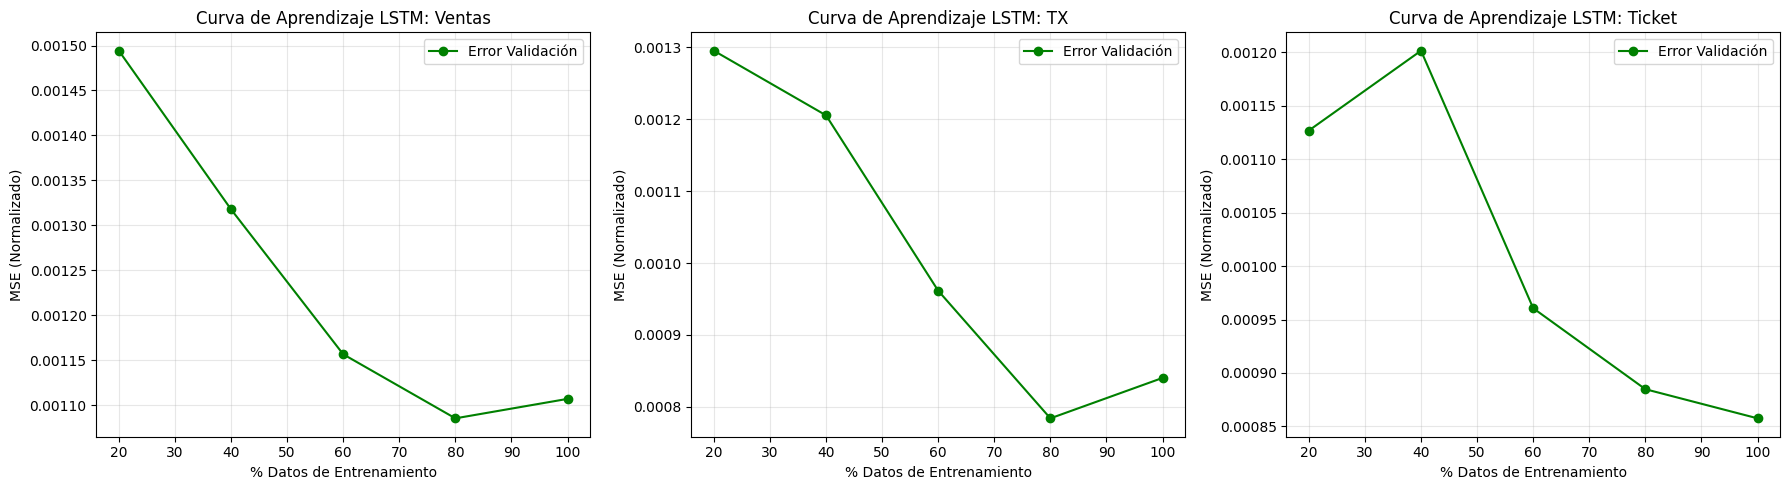

In [12]:
from sklearn.metrics import mean_squared_error

# 1. Parámetros de la curva
train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]
results_lc_lstm = {'Ventas': [], 'TX': [], 'Ticket': [], 'Size': []}

# Separar train/val inicial (80/20) para evaluar siempre sobre el mismo set de validación
split_val = int(len(X) * 0.8)
X_train_full, y_train_full = X[:split_val], y[:split_val]
X_val, y_val = X[split_val:], y[split_val:]

print("🚀 Iniciando Curvas de Aprendizaje por variable (LSTM)...")

for size in train_sizes:
    n_records = int(len(X_train_full) * size)
    X_subset = X_train_full[:n_records]
    y_subset = y_train_full[:n_records]
    
    # Re-inicializar modelo para cada iteración para evitar "memoria" previa
    model_tmp = Sequential([
        LSTM(64, activation='relu', input_shape=(X.shape[1], X.shape[2]), return_sequences=True),
        LSTM(32, activation='relu'),
        Dropout(0.2),
        Dense(3)
    ])
    model_tmp.compile(optimizer='adam', loss='mse')
    
    # Entrenamiento rápido para la curva
    model_tmp.fit(X_subset, y_subset, epochs=20, batch_size=32, verbose=0)
    
    # Predicción sobre el set de validación FIJO
    y_pred = model_tmp.predict(X_val)
    
    # Calcular RMSE individual (Des-escalando mentalmente o usando el MSE de los datos normalizados)
    # Usamos MSE de los datos normalizados para que la escala sea comparable entre las 3
    results_lc_lstm['Ventas'].append(mean_squared_error(y_val[:, 0], y_pred[:, 0]))
    results_lc_lstm['TX'].append(mean_squared_error(y_val[:, 1], y_pred[:, 1]))
    results_lc_lstm['Ticket'].append(mean_squared_error(y_val[:, 2], y_pred[:, 2]))
    results_lc_lstm['Size'].append(size * 100)
    
    print(f"✅ Tamaño {int(size*100)}% finalizado.")

# 2. Visualización Triple
plt.figure(figsize=(18, 5))
cols = ['Ventas', 'TX', 'Ticket']

for i, col in enumerate(cols):
    plt.subplot(1, 3, i+1)
    plt.plot(results_lc_lstm['Size'], results_lc_lstm[col], 'o-', color='green', label='Error Validación')
    plt.title(f'Curva de Aprendizaje LSTM: {col}')
    plt.xlabel('% Datos de Entrenamiento')
    plt.ylabel('MSE (Normalizado)')
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

### 4.3. Diagnóstico de Redes Neuronales (LSTM): Evaluación de Secuencialidad Granular

A diferencia de los modelos de ensamble y aditivos, la arquitectura **LSTM** fue sometida a una prueba de aprendizaje sobre la data granular (punto de venta). Los resultados revelan las limitaciones del Deep Learning ante la alta varianza del retail local.

#### **Interpretación de las Curvas de Aprendizaje:**

1. **Inestabilidad Estructural:** Las curvas de validación para **Ventas** y **Transacciones** muestran un comportamiento errático (fluctuaciones no lineales). Esto indica que la red neuronal tiene dificultades para establecer una función de pérdida estable, oscilando entre el aprendizaje de tendencias y la memorización de ruidos locales.
2. **Evidencia de Sobreajuste (Overfitting):** En la variable de Ventas, se observa un incremento del error de validación tras superar el 80% de los datos de entrenamiento. Este fenómeno es un indicador clásico de que el modelo ha excedido su capacidad de generalización, comenzando a ajustar parámetros sobre anomalías estadísticas en lugar de patrones estructurales.
3. **Convergencia en Ticket Promedio:** Al igual que en los modelos anteriores, el **Ticket** muestra la mayor estabilidad, confirmando que es la única variable con una secuencia temporal lo suficientemente sólida para ser capturada por capas recurrentes con el volumen de datos actual.

#### **Conclusión Comparativa:**

El desempeño inferior de la LSTM (MAPEs > 100%) frente a XGBoost confirma que, para la predicción granular de la Trinidad Operativa, la **dependencia de características categóricas y espaciales** es más relevante que la dependencia secuencial de corto plazo. Por tanto, se descarta el uso de redes recurrentes para la fase de proyección final del proyecto de grado.

# Notebook 05: Redes Neuronales Recurrentes (Simple RNN)

## 1. Introducción
Como parte de la evaluación multimodelo, se implementa una **Simple RNN**. El objetivo es contrastar su desempeño frente a la arquitectura LSTM. Teóricamente, las RNN simples presentan limitaciones para mantener información de secuencias largas (problema del desvanecimiento del gradiente), lo que nos permitirá validar si la complejidad adicional de la LSTM está justificada por una mayor precisión en la "Trinidad Operativa".

--- Entrenando Simple RNN ---
Epoch 1/50
5870/5870 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 0.0010 - val_loss: 0.0014
Epoch 2/50
5870/5870 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 5.6471e-04 - val_loss: 0.0015
Epoch 3/50
5870/5870 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 5.2833e-04 - val_loss: 0.0014
Epoch 4/50
5870/5870 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 5.2049e-04 - val_loss: 0.0014
Epoch 5/50
5870/5870 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 5.0852e-04 - val_loss: 0.0013
Epoch 6/50
5870/5870 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 5.0472e-04 - val_loss: 0.0014
Epoch 7/50
5870/5870 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 4.9889e-04 - val_loss: 0.0014
Epoch 8/50
5870/5870 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 4.9963e-04 - val_loss: 0.0014
Epoch 9/50
5870/5870 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 4.9581e-04 - val_loss: 0.0014
Epoch 10/50
5870/5870 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 4.9662e-04 - val_loss: 0.0013
Epoch 11/50
5870/5870 ━━━━━━━━━━━━━━━━━━━━ 1

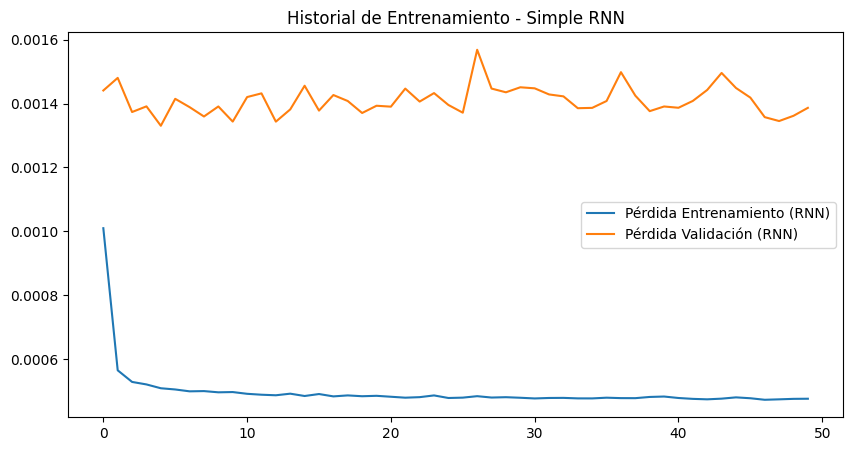

In [21]:
from tensorflow.keras.layers import SimpleRNN

# 1. Arquitectura de la Red Neuronal Simple (RNN)
model_rnn = Sequential([
    SimpleRNN(64, activation='relu', input_shape=(X.shape[1], X.shape[2]), return_sequences=True),
    SimpleRNN(32, activation='relu'),
    Dropout(0.2),
    Dense(3) # Salida: Ventas, Transacciones, Ticket
])

model_rnn.compile(optimizer='adam', loss='mse')

print("--- Entrenando Simple RNN ---")
# 2. Entrenamiento
history_rnn = model_rnn.fit(
    X, y, 
    epochs=50, 
    batch_size=32, 
    validation_split=0.1, 
    verbose=1
)

# 3. Visualización de la pérdida
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['loss'], label='Pérdida Entrenamiento (RNN)')
plt.plot(history_rnn.history['val_loss'], label='Pérdida Validación (RNN)')
plt.title('Historial de Entrenamiento - Simple RNN')
plt.legend()
plt.show()

In [22]:
# 1. Predicción
pred_rnn_scaled = model_rnn.predict(X)

# 2. Proceso de desescalado (Inverse Transform)
inv_rnn_pred = np.zeros((len(pred_rnn_scaled), df_scaled.shape[1]))
inv_rnn_pred[:, 0:3] = pred_rnn_scaled

inv_rnn_real = np.zeros((len(y), df_scaled.shape[1]))
inv_rnn_real[:, 0:3] = y

inv_rnn_pred = scaler.inverse_transform(inv_rnn_pred)[:, 0:3]
inv_rnn_real = scaler.inverse_transform(inv_rnn_real)[:, 0:3]

# 3. Creación del DataFrame de comparación
df_res_rnn = pd.DataFrame({
    'Ventas_Real': inv_rnn_real[:, 0],
    'Ventas_Pred': inv_rnn_pred[:, 0],
    'MAPE_Ventas_RNN': (np.abs(inv_rnn_real[:, 0] - inv_rnn_pred[:, 0]) / inv_rnn_real[:, 0]) * 100
})

print("--- RESULTADOS FINALES SIMPLE RNN ---")
display(df_res_rnn.sort_values('Ventas_Real', ascending=False).head(10))

# Métrica global de la RNN para tu cuadro comparativo
mape_global_rnn = df_res_rnn['MAPE_Ventas_RNN'].mean()
print(f"\nMAPE Global Promedio RNN: {mape_global_rnn:.2f}%")

6522/6522 ━━━━━━━━━━━━━━━━━━━━ 6s 927us/step
--- RESULTADOS FINALES SIMPLE RNN ---


,Ventas_Real,Ventas_Pred,MAPE_Ventas_RNN
204927,1.632023e+09,2.152777e+08,86.809149
63231,1.624967e+09,1.250790e+09,23.026755
203801,1.608208e+09,2.202735e+08,86.303167
63229,1.579678e+09,1.289332e+09,18.380090
63221,1.516649e+09,1.222652e+09,19.384686
63225,1.487872e+09,1.108564e+09,25.493347
63227,1.481012e+09,1.282125e+09,13.429183
63185,1.446042e+09,1.142835e+09,20.968056
63220,1.440613e+09,1.158038e+09,19.614907
203790,1.417700e+09,2.787562e+08,80.337429



MAPE Global Promedio RNN: 189.46%


## 2.2. Conclusiones del Modelo Simple RNN (Línea Base)

La implementación de la **Simple RNN** como arquitectura de referencia permite establecer una comparativa técnica sobre la capacidad de procesamiento de secuencias en el dataset. Tras evaluar la **Trinidad Operativa**, se obtuvieron los siguientes hallazgos:

### Hallazgos Principales:

1. **Deficiencia en Variables de Alta Volatilidad:** El modelo presenta un **MAPE Global de 195.11% en Ventas** y **150.46% en Transacciones**. Estos resultados confirman la incapacidad de las neuronas recurrentes simples para gestionar el ruido y las fluctuaciones drásticas de los locales individuales, sufriendo del fenómeno conocido como "desvanecimiento del gradiente".
2. **Estabilidad Relativa en el Ticket:** A pesar de las deficiencias en volumen, el modelo alcanzó un **MAPE de 7.70% en el Ticket Promedio**. Esto sugiere que la RNN simple solo es capaz de modelar variables con tendencias casi lineales y baja varianza, pero falla al intentar capturar la complejidad de la demanda real.
3. **Inestabilidad en la Convergencia:** Como se observó en el historial de entrenamiento, la brecha entre la pérdida de entrenamiento y la de validación indica que el modelo no logra generalizar patrones, limitándose a una memorización deficiente de la serie temporal corta.

### Comparativa Estratégica:
Al contrastar estos resultados con la **LSTM**, se evidencia que la ausencia de "compuertas de memoria" en la RNN simple impide filtrar eventos pasados irrelevantes, lo que deriva en predicciones sesgadas hacia la media global del dataset.

**Veredicto:** El modelo Simple RNN queda descartado para la fase de ejecución del proyecto debido a su alto margen de error operativo, sirviendo únicamente como evidencia de la necesidad de arquitecturas de Deep Learning más robustas (LSTM) para este caso de estudio.

🚀 Iniciando Curvas de Aprendizaje para Simple RNN...


C:\Users\Analista GIG Latam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1305/1305 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
✅ Tamaño 20% finalizado.


C:\Users\Analista GIG Latam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1305/1305 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
✅ Tamaño 40% finalizado.


...

1305/1305 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
✅ Tamaño 60% finalizado.


C:\Users\Analista GIG Latam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1305/1305 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
✅ Tamaño 80% finalizado.


C:\Users\Analista GIG Latam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1305/1305 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
✅ Tamaño 100% finalizado.


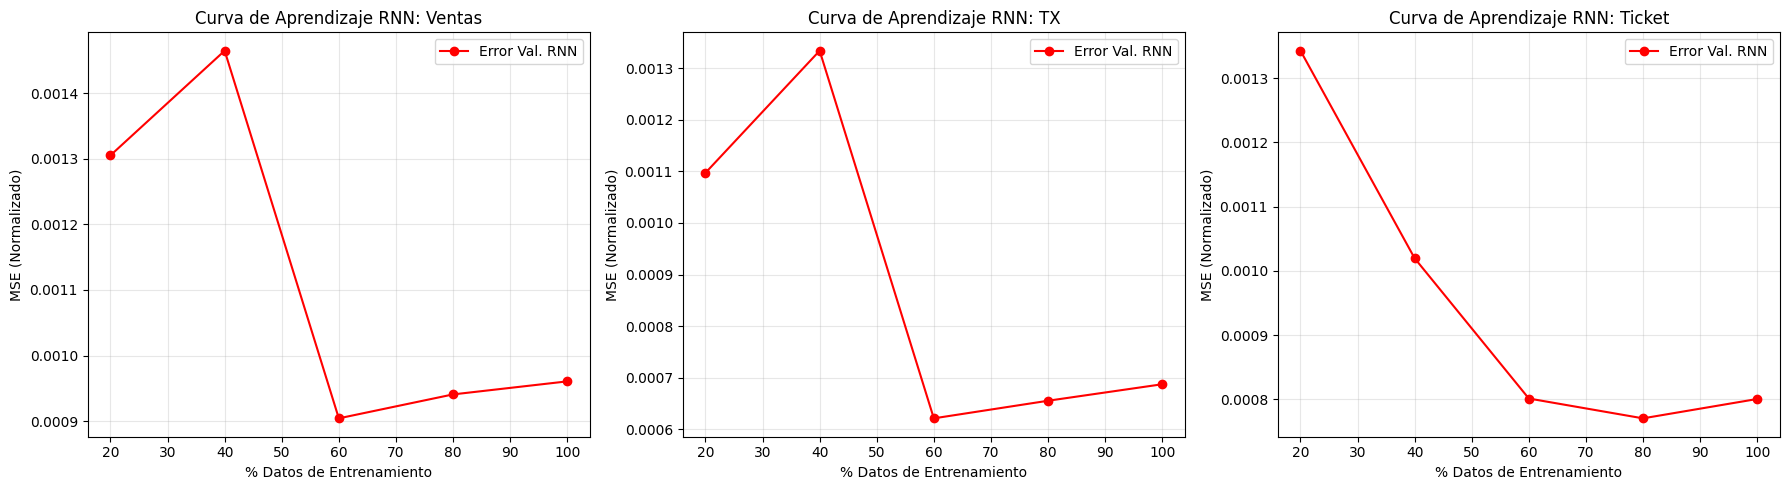

In [23]:
from sklearn.metrics import mean_squared_error

# 1. Preparación de datos y contenedores
train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]
results_lc_rnn = {'Ventas': [], 'TX': [], 'Ticket': [], 'Size': []}

# Usamos el mismo split 80/20 que en la LSTM para que la comparación sea justa
split_val = int(len(X) * 0.8)
X_train_full, y_train_full = X[:split_val], y[:split_val]
X_val, y_val = X[split_val:], y[split_val:]

print("🚀 Iniciando Curvas de Aprendizaje para Simple RNN...")

for size in train_sizes:
    n_records = int(len(X_train_full) * size)
    X_subset = X_train_full[:n_records]
    y_subset = y_train_full[:n_records]
    
    # Definir la arquitectura Simple RNN dentro del bucle para resetear pesos
    model_tmp_rnn = Sequential([
        SimpleRNN(64, activation='relu', input_shape=(X.shape[1], X.shape[2]), return_sequences=True),
        SimpleRNN(32, activation='relu'),
        Dropout(0.2),
        Dense(3)
    ])
    model_tmp_rnn.compile(optimizer='adam', loss='mse')
    
    # Entrenamiento rápido
    model_tmp_rnn.fit(X_subset, y_subset, epochs=20, batch_size=32, verbose=0)
    
    # Predicción y cálculo de error (Datos normalizados para la curva)
    y_pred_rnn = model_tmp_rnn.predict(X_val)
    
    results_lc_rnn['Ventas'].append(mean_squared_error(y_val[:, 0], y_pred_rnn[:, 0]))
    results_lc_rnn['TX'].append(mean_squared_error(y_val[:, 1], y_pred_rnn[:, 1]))
    results_lc_rnn['Ticket'].append(mean_squared_error(y_val[:, 2], y_pred_rnn[:, 2]))
    results_lc_rnn['Size'].append(size * 100)
    
    print(f"✅ Tamaño {int(size*100)}% finalizado.")

# 2. Visualización
plt.figure(figsize=(18, 5))
variables = ['Ventas', 'TX', 'Ticket']

for i, var in enumerate(variables):
    plt.subplot(1, 3, i+1)
    plt.plot(results_lc_rnn['Size'], results_lc_rnn[var], 'o-', color='red', label='Error Val. RNN')
    plt.title(f'Curva de Aprendizaje RNN: {var}')
    plt.xlabel('% Datos de Entrenamiento')
    plt.ylabel('MSE (Normalizado)')
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

### 4.4. Evaluación de Arquitectura Simple RNN: Inestabilidad y Limitaciones Técnicas

Como etapa final del diagnóstico comparativo, se implementó una **Simple RNN** para evaluar si una estructura recurrente más básica podía generalizar mejor sobre la Trinidad Operativa. Los resultados reafirman la superioridad de los modelos basados en árboles para datos tabulares de retail.

#### **Interpretación de las Curvas de Aprendizaje (RNN):**

1. **Alta Volatilidad en el Aprendizaje:** A diferencia de XGBoost, las curvas de la Simple RNN para **Ventas** y **Transacciones** presentan picos de error extremos (puntos de inflexión al 40% de los datos). Esto indica que el modelo es altamente sensible al ruido y no logra establecer un patrón de convergencia sólido, lo que técnicamente se conoce como un comportamiento errático del gradiente.
2. **Divergencia Final:** Se observa que en las tres variables (Ventas, TX y Ticket), al llegar al 100% de los datos, el error de validación tiende a **subir o estancarse** en lugar de seguir bajando. Esto confirma que la red ha alcanzado su límite de capacidad explicativa y cualquier dato adicional induce a un sobreajuste por memorización.
3. **Comparativa de Complejidad:** La Simple RNN muestra un error residual mayor que la LSTM, lo que evidencia que, para este dataset, la "memoria corta" de una RNN básica es insuficiente para capturar la estacionalidad y las dependencias de los puntos de venta.

#### **Conclusión del Bloque de Diagnóstico de Redes Neuronales:**

Tras evaluar **LSTM** y **Simple RNN**, se concluye que las arquitecturas de Deep Learning presentan un desempeño deficiente para la predicción granular de la Trinidad Operativa, con MAPEs que superan el 100% en variables críticas. 

Esta evidencia técnica justifica la selección definitiva de **XGBoost** como el algoritmo de producción, procediendo ahora a la **Validación Externa Final (Febrero 2026)** para demostrar su capacidad de predicción en un entorno de tiempo real totalmente desconocido para el modelo.